# MWAMNet — Stage 2: external validation

The external set is [The Wildfire Dataset](https://www.kaggle.com/datasets/elmadafri/the-wildfire-dataset)
(El-Madafri et al., *Forests* 2023) — 2,700 images, built specifically to be hard. It
deliberately includes **fire confounding elements**: sunsets, reddish autumn foliage,
sunlight reflections, fog and cloud, motion blur.

**Nothing is retrained on it.** The heads are trained on the original Kaggle features
exactly as in Stage 1, then run once over the new images.

In [ ]:
#@title 1 · Setup, seeds and configuration
!pip -q install kagglehub statsmodels

import os, sys, json, math, random, hashlib, time, gc
import numpy as np

CFG = dict(
    KAGGLE_ID  = "alik05/forest-fire-dataset",
    IMG        = 224,
    SEED       = 42,
    VAL_FRAC   = 0.20,
    AUG_COPIES = 4,        # augmented copies per training image (0 = no augmentation)
    EPOCHS     = 100,
    BATCH      = 32,
    PATIENCE   = 15,
    N_SEEDS    = 5,        # repeats per model -> mean +/- SD
    EXTRACT_BS = 16,       # feature-extraction batch; auto-halves on GPU OOM
    HUE        = 0.10,
    L2         = 0.01,
    DROPOUT    = 0.5,
    LR         = 1e-4,
    WD         = 1e-4,
)

# ---- reproducibility -------------------------------------------------------
os.environ["PYTHONHASHSEED"] = str(CFG["SEED"])
random.seed(CFG["SEED"]); np.random.seed(CFG["SEED"])
import tensorflow as tf


for _g in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(_g, True)
    except Exception as _e:
        print("memory-growth setting skipped:", _e)

tf.keras.utils.set_random_seed(CFG["SEED"])

print("TensorFlow :", tf.__version__)
print("Keras      :", tf.keras.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU        :", gpus or "NONE  <-- switch runtime to T4 GPU")


import shutil
SUBS   = ("features", "results", "figures", "models")
WORK   = "/content/MWAMNet_revision"
MIRROR = None

for sub in SUBS:
    os.makedirs(os.path.join(WORK, sub), exist_ok=True)

try:
    from google.colab import drive
    drive.mount("/content/drive")
    cand = "/content/drive/MyDrive/MWAMNet_revision"
    for sub in SUBS:
        os.makedirs(os.path.join(cand, sub), exist_ok=True)
    if all(os.path.isdir(os.path.join(cand, s)) for s in SUBS):
        MIRROR = cand
    else:
        print("Drive mounted but not writable - local only.")
except Exception as e:
    print("Drive unavailable (%s) - local only." % e)

OUT = WORK

def backup():

    if not MIRROR:
        return
    n = 0
    for sub in SUBS:
        src, dst = os.path.join(WORK, sub), os.path.join(MIRROR, sub)
        os.makedirs(dst, exist_ok=True)
        for f in os.listdir(src):
            a, b = os.path.join(src, f), os.path.join(dst, f)
            if not os.path.exists(b) or os.path.getmtime(a) > os.path.getmtime(b) + 1:
                try:
                    shutil.copy2(a, b); n += 1
                except Exception as e:
                    print("   backup failed for %s (%s)" % (f, e))
    print("   backed up %d file(s) to Drive" % n)

def restore():

    if not MIRROR:
        return
    n = 0
    for sub in SUBS:
        src, dst = os.path.join(MIRROR, sub), os.path.join(WORK, sub)
        if not os.path.isdir(src):
            continue
        for f in os.listdir(src):
            a, b = os.path.join(src, f), os.path.join(dst, f)
            if not os.path.exists(b):
                shutil.copy2(a, b); n += 1
    if n:
        print("Restored %d cached file(s) from Drive - finished stages will be skipped." % n)

restore()
print("Working in :", WORK)
print("Mirrored to:", MIRROR or "nothing - DOWNLOAD")

json.dump(CFG, open(os.path.join(WORK, "config.json"), "w"), indent=2)

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mounted at /content/drive
Restored 32 cached file(s) from Drive - finished stages will be skipped.
Working in : /content/MWAMNet_revision
Mirrored to: /content/drive/MyDrive/MWAMNet_revision


In [ ]:
#@title 2 · Download, load, and build the split
import kagglehub, glob
from PIL import Image
from sklearn.model_selection import train_test_split

root = kagglehub.dataset_download(CFG["KAGGLE_ID"])
base = glob.glob(os.path.join(root, "**", "Forest Fire Dataset"), recursive=True)[0]
TRAIN_DIR, TEST_DIR = os.path.join(base, "Training"), os.path.join(base, "Testing")

S = CFG["IMG"]

def load(paths):
    # Load images as uint8 [0,255] RGB at S x S -> 286 MB for the whole dataset.
    a = np.zeros((len(paths), S, S, 3), dtype=np.uint8)
    for i, p in enumerate(paths):
        with Image.open(p) as im:
            a[i] = np.asarray(im.convert("RGB").resize((S, S), Image.BILINEAR))
    return a

# --- training pool: label from the class folder ---
pool_paths, pool_y = [], []
for cls, lab in (("nofire", 0), ("fire", 1)):
    fs = sorted(glob.glob(os.path.join(TRAIN_DIR, cls, "*.jpg")))
    pool_paths += fs; pool_y += [lab] * len(fs)
pool_y = np.array(pool_y, dtype=np.int32)

# --- held-out test set: label from the filename prefix ---
test_paths = sorted(glob.glob(os.path.join(TEST_DIR, "*.jpg")))
test_y = np.array([0 if os.path.basename(p).lower().startswith("nofire") else 1
                   for p in test_paths], dtype=np.int32)

tr_p, va_p, tr_y, va_y = train_test_split(
    pool_paths, pool_y, test_size=CFG["VAL_FRAC"],
    random_state=CFG["SEED"], stratify=pool_y)

X_tr, X_va, X_te = load(tr_p), load(va_p), load(test_paths)
y_tr, y_va, y_te = tr_y, va_y, test_y

def dist(y): return "nofire=%d fire=%d" % ((y == 0).sum(), (y == 1).sum())
print("train %4d  %s" % (len(y_tr), dist(y_tr)))
print("val   %4d  %s" % (len(y_va), dist(y_va)))
print("TEST  %4d  %s   <- held out, never seen in training" % (len(y_te), dist(y_te)))

np.save(os.path.join(OUT, "results", "y_test.npy"), y_te)
json.dump({"train": tr_p, "val": va_p, "test": test_paths},
          open(os.path.join(OUT, "results", "split_manifest.json"), "w"))
print("\nSplit manifest saved - this is the Table 1 you will report.")

Using Colab cache for faster access to the 'forest-fire-dataset' dataset.
train 1216  nofire=608 fire=608
val    304  nofire=152 fire=152
TEST   380  nofire=190 fire=190   <- held out, never seen in training

Split manifest saved - this is the Table 1 you will report.


In [ ]:
#@title 3 · Feature extraction
from tensorflow.keras.applications import (densenet, mobilenet_v3, resnet50,
                                           vgg16, inception_v3)
from tensorflow.keras.applications import (DenseNet201, MobileNetV3Large,
                                           ResNet50, VGG16, InceptionV3)

BACKBONES = {
    "DenseNet201":      (DenseNet201,      densenet.preprocess_input),
    "MobileNetV3Large": (MobileNetV3Large, mobilenet_v3.preprocess_input),
    "ResNet50":         (ResNet50,         resnet50.preprocess_input),
    "VGG16":            (VGG16,            vgg16.preprocess_input),
    "InceptionV3":      (InceptionV3,      inception_v3.preprocess_input),
}


USE_JPEG = True

def aug_one(img01, seed):
    im = tf.image.stateless_random_flip_left_right(img01, seed)
    im = tf.image.stateless_random_brightness(im, 0.10,     seed + 1)
    im = tf.image.stateless_random_contrast(im, 0.9, 1.1,   seed + 2)
    im = tf.image.stateless_random_saturation(im, 0.9, 1.1, seed + 3)
    im = tf.image.stateless_random_hue(im, CFG["HUE"],      seed + 4)
    im = tf.clip_by_value(im, 0.0, 1.0)
    if USE_JPEG:
        im = tf.image.stateless_random_jpeg_quality(im, 75, 100, seed + 5)
    return tf.cast(tf.round(im * 255.0), tf.uint8)

def build_augmented(X):

    blocks = [X]
    with tf.device("/CPU:0"):
        for c in range(1, CFG["AUG_COPIES"] + 1):
            o = np.empty_like(X)
            for i in range(len(X)):
                s = tf.constant([i, c * 7919 + 13], dtype=tf.int32)
                o[i] = aug_one(tf.cast(X[i], tf.float32) / 255.0, s).numpy()
            blocks.append(o)
            print("   augmented copy %d/%d" % (c, CFG["AUG_COPIES"]))
    out = np.concatenate(blocks)
    del blocks; gc.collect()
    return out

FEAT  = os.path.join(OUT, "features")
todo  = [b for b in BACKBONES if not os.path.exists(os.path.join(FEAT, b + "_test.npy"))]
print("to extract:", todo or "nothing - all cached")

if todo:
    try:
        aug_one(tf.zeros((S, S, 3)), tf.constant([1, 1], tf.int32))
    except Exception as e:
        USE_JPEG = False
        print("JPEG-quality augmentation unavailable (%s) - continuing without it." % type(e).__name__)
    t0 = time.time()
    X_tr_all = build_augmented(X_tr) if CFG["AUG_COPIES"] else X_tr
    print("augmented training pool: %d images  (%.1f min)"
          % (len(X_tr_all), (time.time() - t0) / 60))

def extract(net, prep, u8, bs=None):

    bs  = bs or CFG["EXTRACT_BS"]
    out = np.empty((len(u8), net.output_shape[-1]), dtype=np.float32)
    i   = 0
    while i < len(u8):
        try:
            b = tf.cast(u8[i:i + bs], tf.float32)
            out[i:i + int(b.shape[0])] = net(prep(b), training=False).numpy()
            i += bs
        except tf.errors.ResourceExhaustedError:
            if bs == 1:
                raise
            bs = max(1, bs // 2)
            gc.collect()
            print("   GPU out of memory - retrying at batch size %d" % bs)
    return out

for name in todo:
    t0 = time.time()
    Base, prep = BACKBONES[name]
    net = Base(weights="imagenet", include_top=False,
               input_shape=(S, S, 3), pooling="avg")
    net.trainable = False
    tag = os.path.join(FEAT, name)
    np.save(tag + "_train.npy", extract(net, prep, X_tr_all))
    np.save(tag + "_val.npy",   extract(net, prep, X_va))
    np.save(tag + "_test.npy",  extract(net, prep, X_te))
    dim = np.load(tag + "_test.npy", mmap_mode="r").shape[1]
    del net
    tf.keras.backend.clear_session(); gc.collect()
    print("%-18s dim=%-5d  %.1f min" % (name, dim, (time.time() - t0) / 60))

if todo:
    del X_tr_all
    gc.collect()

N_TR     = len(y_tr)
y_tr_aug = np.tile(y_tr, CFG["AUG_COPIES"] + 1)
np.save(os.path.join(OUT, "results", "y_train_aug.npy"), y_tr_aug)
np.save(os.path.join(OUT, "results", "y_val.npy"), y_va)
backup()
print("\nCached. Everything below runs in seconds.")

to extract: nothing - all cached
   backed up 4 file(s) to Drive

Cached. Everything below runs in seconds.


In [ ]:
#@title 4 · Head architecture and training routine
from tensorflow.keras.layers import (Input, Dense, BatchNormalization,
                                     Dropout, Concatenate)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2 as L2reg
from tensorflow.keras.callbacks import EarlyStopping

MODELS = {
    "MWAMNet":          ["DenseNet201", "MobileNetV3Large"],
    "DenseNet201":      ["DenseNet201"],
    "MobileNetV3Large": ["MobileNetV3Large"],
    "ResNet50":         ["ResNet50"],
    "VGG16":            ["VGG16"],
    "InceptionV3":      ["InceptionV3"],
}

def load_feats(backbones, split):
    return [np.load(os.path.join(OUT, "features", "%s_%s.npy" % (b, split)))
            for b in backbones]

def build_head(dims, l2v, drop, units=(1024, 512)):
    ins = [Input(shape=(d,)) for d in dims]
    br  = [Dropout(drop)(BatchNormalization()(i)) for i in ins]
    x   = Concatenate()(br) if len(br) > 1 else br[0]
    for u in units:
        x = Dense(u, activation="relu", kernel_regularizer=L2reg(l2v))(x)
        x = BatchNormalization()(x)
        x = Dropout(drop)(x)
    return Model(ins, Dense(1, activation="sigmoid")(x))

def run(backbones, seed, augment=True, l2v=None, drop=None,
        cosine=True, epochs=None, units=(1024, 512), verbose=0):
    # Train one head and return its probabilities on the held-out test set.
    l2v  = CFG["L2"]      if l2v   is None else l2v
    drop = CFG["DROPOUT"] if drop  is None else drop
    ep   = CFG["EPOCHS"]  if epochs is None else epochs
    tf.keras.utils.set_random_seed(seed)

    Xtr = load_feats(backbones, "train")
    ytr = y_tr_aug
    if not augment:                                   # first block = originals only
        Xtr = [f[:N_TR] for f in Xtr]; ytr = y_tr
    Xva, Xte = load_feats(backbones, "val"), load_feats(backbones, "test")

    steps = math.ceil(len(ytr) / CFG["BATCH"]) * ep
    lr = (tf.keras.optimizers.schedules.CosineDecay(CFG["LR"], steps, alpha=1e-6)
          if cosine else CFG["LR"])
    m = build_head([f.shape[1] for f in Xtr], l2v, drop, units)
    m.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=lr,
                                                  weight_decay=CFG["WD"]),
              loss="binary_crossentropy", metrics=["accuracy"])
    m.fit(Xtr, ytr, validation_data=(Xva, y_va),
          epochs=ep, batch_size=CFG["BATCH"], verbose=verbose,
          callbacks=[EarlyStopping(monitor="val_accuracy", mode="max",
                                   patience=CFG["PATIENCE"],
                                   restore_best_weights=True)])
    return m.predict(Xte, verbose=0).ravel(), m

print("Head ready. MWAMNet input dim =",
      sum(f.shape[1] for f in load_feats(MODELS["MWAMNet"], "test")))

Head ready. MWAMNet input dim = 2880


In [ ]:
#@title 5 · Download The Wildfire Dataset and build labels
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, cohen_kappa_score, confusion_matrix)
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.contingency_tables import mcnemar
plt.rcParams.update({"font.size": 12, "font.family": "DejaVu Sans",
                     "savefig.dpi": 300, "figure.dpi": 120})

EXT_ID   = "elmadafri/the-wildfire-dataset"
EXT_NAME = "The Wildfire Dataset"
IMGEXT   = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

ext_root = kagglehub.dataset_download(EXT_ID)
print("ROOT:", ext_root)
print("=" * 72)
for dp, dn, fn in os.walk(ext_root):
    dn.sort()
    d = dp[len(ext_root):].count(os.sep)
    if d <= 3:
        imgs = [f for f in fn if os.path.splitext(f)[1].lower() in IMGEXT]
        print("  " * d + "[%s]  images=%d  subdirs=%d"
              % (os.path.basename(dp) or ".", len(imgs), len(dn)))
print("=" * 72)

recs = []
for dp, _, fn in os.walk(ext_root):
    parts = [p.lower() for p in dp[len(ext_root):].split(os.sep) if p]
    if   any(p == "nofire" for p in parts): lab = 0
    elif any(p == "fire"   for p in parts): lab = 1
    else: continue
    sub = parts[-1] if parts[-1] not in ("fire", "nofire") else "unspecified"
    for f in fn:
        if os.path.splitext(f)[1].lower() in IMGEXT:
            recs.append((os.path.join(dp, f), lab, sub))

ext_paths = [r[0] for r in recs]
y_ext     = np.array([r[1] for r in recs], dtype=np.int32)
sub_ext   = np.array([r[2] for r in recs])

from collections import Counter
print("External images: %d   (nofire=%d, fire=%d)"
      % (len(y_ext), (y_ext == 0).sum(), (y_ext == 1).sum()))
print("\nSubclasses:")
for s, n in Counter(sub_ext).most_common():
    f = int((y_ext[sub_ext == s] == 1).sum())
    print("   %-46s n=%-5d fire=%-5d nofire=%d" % (s, n, f, n - f))
assert len(y_ext) > 0, 'No labelled images found - check the printed folder structure.'


Using Colab cache for faster access to the 'the-wildfire-dataset' dataset.
ROOT: /kaggle/input/the-wildfire-dataset
[the-wildfire-dataset]  images=0  subdirs=1
  [the_wildfire_dataset_2n_version]  images=0  subdirs=3
    [test]  images=0  subdirs=2
      [fire]  images=159  subdirs=0
      [nofire]  images=251  subdirs=0
    [train]  images=0  subdirs=2
      [fire]  images=730  subdirs=0
      [nofire]  images=1157  subdirs=0
    [val]  images=0  subdirs=2
      [fire]  images=156  subdirs=0
      [nofire]  images=246  subdirs=0
External images: 2699   (nofire=1654, fire=1045)

Subclasses:
   unspecified                                    n=2699  fire=1045  nofire=1654


## 6 · Load and featurise the external images

Same five backbones, same `preprocess_input` for each, same 224×224 input.

In [ ]:
#@title 6 · Load and extract external features  (slow — ~10–20 min)
def load_big(paths, chunk_msg=400):
    a = np.zeros((len(paths), S, S, 3), dtype=np.uint8)
    for i, p in enumerate(paths):
        try:
            with Image.open(p) as im:
                im.draft("RGB", (S * 2, S * 2))     # DCT-scaled decode: much faster
                a[i] = np.asarray(im.convert("RGB").resize((S, S), Image.BILINEAR))
        except Exception as e:
            print("   unreadable, skipped as black frame: %s (%s)" % (os.path.basename(p), e))
        if (i + 1) % chunk_msg == 0:
            print("   loaded %d/%d" % (i + 1, len(paths)))
    return a

EXTF = os.path.join(OUT, "features")
need = [b for b in BACKBONES if not os.path.exists(os.path.join(EXTF, b + "_ext.npy"))]
print("to extract:", need or "nothing - all cached")

if need:
    t0 = time.time()
    X_ext = load_big(ext_paths)
    print("decoded %d images in %.1f min" % (len(X_ext), (time.time() - t0) / 60))
    for name in need:
        t1 = time.time()
        Base, prep = BACKBONES[name]
        net = Base(weights="imagenet", include_top=False,
                   input_shape=(S, S, 3), pooling="avg")
        net.trainable = False
        np.save(os.path.join(EXTF, name + "_ext.npy"), extract(net, prep, X_ext))
        del net; tf.keras.backend.clear_session(); gc.collect()
        print("%-18s  %.1f min" % (name, (time.time() - t1) / 60))
    del X_ext; gc.collect()

np.save(os.path.join(OUT, "results", "y_ext.npy"), y_ext)
np.save(os.path.join(OUT, "results", "sub_ext.npy"), sub_ext)
backup()

to extract: ['DenseNet201', 'MobileNetV3Large', 'ResNet50', 'VGG16', 'InceptionV3']
   loaded 400/2699


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94487082 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (101859328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96631920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


   loaded 800/2699


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (104688771 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


   loaded 1200/2699


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (89747104 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


   loaded 1600/2699
   loaded 2000/2699
   loaded 2400/2699
decoded 2699 images in 8.0 min
74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
DenseNet201         2.5 min
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MobileNetV3Large    0.6 min
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
ResNet50            0.9 min
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
VGG16               0.4 min
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
InceptionV3         1.1 min
   backed up 7 file(s) to Drive


## 7 · Evaluate: in-domain versus out-of-domain

Each head is trained on the Kaggle training features exactly as in Stage 1 — same seeds,
same everything — then run over both test sets. The external set is class-imbalanced
(roughly 1,047 fire to 1,653 no-fire), so **balanced accuracy** is reported alongside
plain accuracy; plain accuracy alone would flatter a model that simply predicts
"no fire" more often.

In [ ]:
#@title 7 · External metrics
from sklearn.metrics import balanced_accuracy_score

def load_ext(bbs):
    return [np.load(os.path.join(OUT, "features", "%s_ext.npy" % b)) for b in bbs]

ext_probs, in_probs, rows = {}, {}, []
for mname, bbs in MODELS.items():
    Pe, Pi = [], []
    for s in range(CFG["N_SEEDS"]):
        p_in, mdl = run(bbs, seed=CFG["SEED"] + s)
        Pi.append(p_in)
        Pe.append(mdl.predict(load_ext(bbs), verbose=0).ravel())
    ext_probs[mname], in_probs[mname] = np.stack(Pe), np.stack(Pi)
    np.save(os.path.join(OUT, "results", "%s_ext_probs.npy" % mname), ext_probs[mname])

    accs_e = np.array([accuracy_score(y_ext, (p > .5).astype(int)) for p in Pe])
    k  = int(np.argsort(accs_e)[len(accs_e) // 2])
    ye = (Pe[k] > .5).astype(int)
    yi = (Pi[k] > .5).astype(int)
    n, c = len(y_ext), int((ye == y_ext).sum())
    lo, hi = proportion_confint(c, n, alpha=0.05, method="wilson")
    rows.append(dict(
        Model=mname,
        InDomain=round(accuracy_score(y_te, yi), 4),
        External=round(accuracy_score(y_ext, ye), 4),
        Drop=round(accuracy_score(y_te, yi) - accuracy_score(y_ext, ye), 4),
        BalancedAcc=round(balanced_accuracy_score(y_ext, ye), 4),
        CI95="[%.4f, %.4f]" % (lo, hi),
        Precision=round(precision_score(y_ext, ye), 4),
        Recall=round(recall_score(y_ext, ye), 4),
        F1=round(f1_score(y_ext, ye), 4),
        Kappa=round(cohen_kappa_score(y_ext, ye), 4),
        Mean_SD="%.4f ± %.4f" % (accs_e.mean(), accs_e.std(ddof=1)),
    ))
    print("%-18s in=%.4f  ext=%.4f  bal=%.4f  (drop %.4f)"
          % (mname, rows[-1]["InDomain"], rows[-1]["External"],
             rows[-1]["BalancedAcc"], rows[-1]["Drop"]))

E = pd.DataFrame(rows).sort_values("BalancedAcc", ascending=False)
E.to_csv(os.path.join(OUT, "results", "external.csv"), index=False)
display(E)
backup()

MWAMNet            in=0.9895  ext=0.7518  bal=0.7143  (drop 0.2377)
DenseNet201        in=0.9842  ext=0.7399  bal=0.7064  (drop 0.2443)
MobileNetV3Large   in=0.9842  ext=0.7192  bal=0.6840  (drop 0.2651)
ResNet50           in=0.9895  ext=0.7277  bal=0.6848  (drop 0.2618)
VGG16              in=0.9789  ext=0.6795  bal=0.6309  (drop 0.2994)
InceptionV3        in=0.9842  ext=0.7644  bal=0.7300  (drop 0.2199)


,Model,InDomain,External,Drop,BalancedAcc,CI95,Precision,Recall,F1,Kappa,Mean_SD
5,InceptionV3,0.9842,0.7644,0.2199,0.7300,"[0.7480, 0.7800]",0.7559,0.5780,0.6551,0.4809,0.7612 ± 0.0206
0,MWAMNet,0.9895,0.7518,0.2377,0.7143,"[0.7351, 0.7677]",0.7432,0.5483,0.6311,0.4504,0.7542 ± 0.0053
1,DenseNet201,0.9842,0.7399,0.2443,0.7064,"[0.7230, 0.7561]",0.7084,0.5579,0.6242,0.4296,0.7392 ± 0.0028
3,ResNet50,0.9895,0.7277,0.2618,0.6848,"[0.7106, 0.7441]",0.7141,0.4947,0.5845,0.3917,0.7259 ± 0.0080
2,MobileNetV3Large,0.9842,0.7192,0.2651,0.6840,"[0.7019, 0.7358]",0.6756,0.5282,0.5929,0.3834,0.7192 ± 0.0215
4,VGG16,0.9789,0.6795,0.2994,0.6309,"[0.6617, 0.6969]",0.6308,0.4153,0.5009,0.2793,0.6779 ± 0.0088


   backed up 7 file(s) to Drive


In [ ]:
#@title 8 · McNemar on the external set
REP_EXT = {}
for m, P in ext_probs.items():
    accs = np.array([accuracy_score(y_ext, (p > .5).astype(int)) for p in P])
    REP_EXT[m] = (P[int(np.argsort(accs)[len(accs) // 2])] > .5).astype(int)

base, out = REP_EXT["MWAMNet"], []
for m, yp in REP_EXT.items():
    if m == "MWAMNet":
        continue
    a = (base == y_ext); b = (yp == y_ext)
    n01, n10 = int((a & ~b).sum()), int((~a & b).sum())
    r = mcnemar([[int((a & b).sum()), n01], [n10, int((~a & ~b).sum())]],
                exact=(n01 + n10) < 25, correction=True)
    out.append(dict(Comparison="MWAMNet vs %s" % m,
                    MWAMNet_only_correct=n01, Baseline_only_correct=n10,
                    p_value=float(r.pvalue),
                    Significant="yes" if r.pvalue < 0.05 else "no"))
ME = pd.DataFrame(out)
ME.to_csv(os.path.join(OUT, "results", "mcnemar_external.csv"), index=False)
display(ME)
print("\nSignificant comparisons: %d of %d" % ((ME.Significant == "yes").sum(), len(ME)))
backup()

,Comparison,MWAMNet_only_correct,Baseline_only_correct,p_value,Significant
0,MWAMNet vs DenseNet201,111,79,2.451400e-02,yes
1,MWAMNet vs MobileNetV3Large,186,98,2.436731e-07,yes
2,MWAMNet vs ResNet50,183,118,2.252269e-04,yes
3,MWAMNet vs VGG16,315,120,1.383634e-20,yes
4,MWAMNet vs InceptionV3,144,178,6.591252e-02,no



Significant comparisons: 4 of 5
   backed up 1 file(s) to Drive


In [ ]:
#@title 9 · Per-subclass accuracy
subs = sorted(set(sub_ext), key=lambda s: -int((sub_ext == s).sum()))
tbl = []
for m, yp in REP_EXT.items():
    r = {"Model": m}
    for s in subs:
        k = sub_ext == s
        r["%s (n=%d)" % (s[:26], k.sum())] = round(float((yp[k] == y_ext[k]).mean()), 4)
    tbl.append(r)
P = pd.DataFrame(tbl).set_index("Model")
P.to_csv(os.path.join(OUT, "results", "per_subclass.csv"))
display(P)

worst = P.mean(axis=0).sort_values()
print("\nHardest subclasses, averaged over all six models:")
for s, v in worst.head(4).items():
    print("   %-40s %.4f" % (s, v))
backup()

,unspecified (n=2699)
Model,
MWAMNet,0.7518
DenseNet201,0.7399
MobileNetV3Large,0.7192
ResNet50,0.7277
VGG16,0.6795
InceptionV3,0.7644



Hardest subclasses, averaged over all six models:
   unspecified (n=2699)                     0.7304
   backed up 1 file(s) to Drive


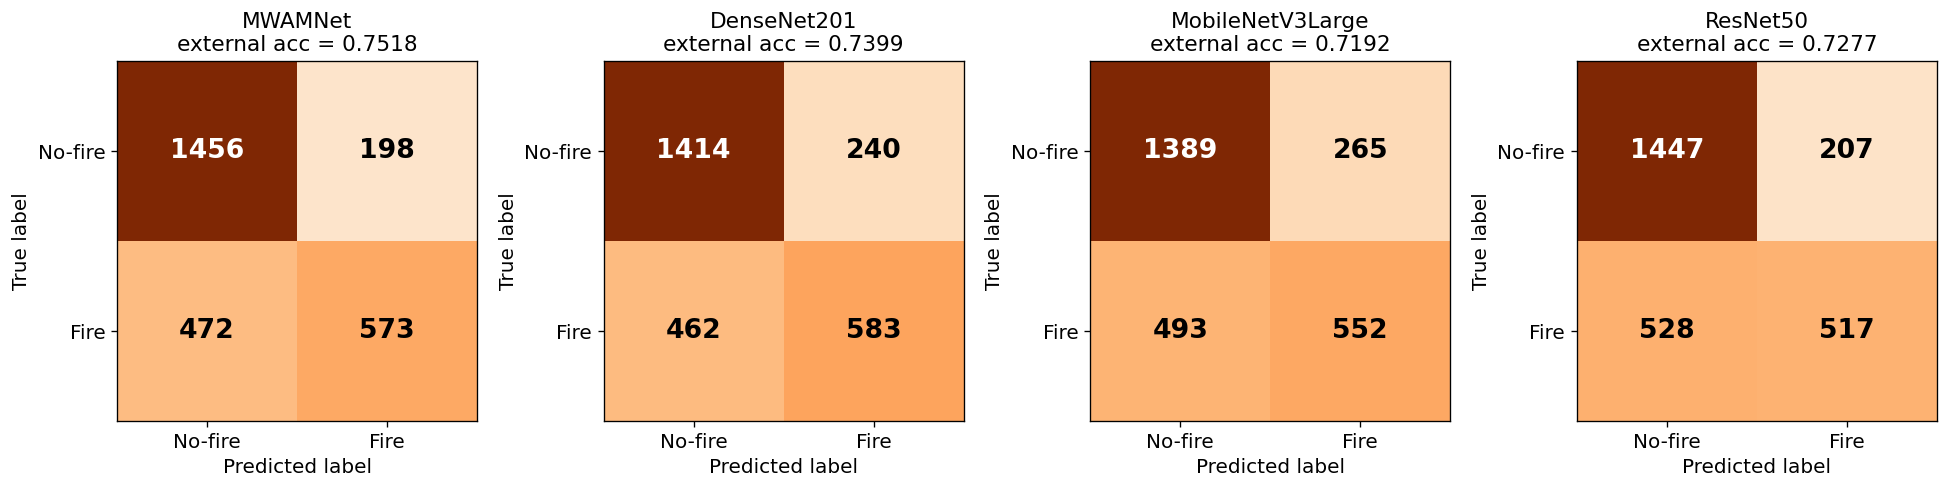

MWAMNet             nofire[ 1456,  198]  fire[  472,  573]
DenseNet201         nofire[ 1414,  240]  fire[  462,  583]
MobileNetV3Large    nofire[ 1389,  265]  fire[  493,  552]
ResNet50            nofire[ 1447,  207]  fire[  528,  517]
VGG16               nofire[ 1400,  254]  fire[  611,  434]
InceptionV3         nofire[ 1459,  195]  fire[  441,  604]
   backed up 2 file(s) to Drive

Send me: results/external.csv, results/mcnemar_external.csv,
         results/per_subclass.csv, and the matrices printed above.


In [ ]:
#@title 10 · External confusion matrices and summary
show = list(MODELS)[:4]
fig, axes = plt.subplots(1, len(show), figsize=(4.1 * len(show), 4.1))
for ax, m in zip(np.atleast_1d(axes), show):
    cm = confusion_matrix(y_ext, REP_EXT[m])
    ax.imshow(cm, cmap="Oranges", vmin=0, vmax=cm.max())
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=16,
                    fontweight="bold",
                    color="white" if cm[i, j] > cm.max() * .55 else "black")
    ax.set_xticks([0, 1], ["No-fire", "Fire"]); ax.set_yticks([0, 1], ["No-fire", "Fire"])
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    ax.set_title("%s\nexternal acc = %.4f" % (m, (REP_EXT[m] == y_ext).mean()), fontsize=13)
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(os.path.join(OUT, "figures", "confusion_external.%s" % ext),
                bbox_inches="tight")
plt.show()

for m in MODELS:
    tn, fp, fn, tp = confusion_matrix(y_ext, REP_EXT[m]).ravel()
    print("%-18s  nofire[%5d,%5d]  fire[%5d,%5d]" % (m, tn, fp, fn, tp))
backup()
print("=" * 60)
print("Send me: results/external.csv, results/mcmemar_external.csv,")
print("         results/per_subclass.csv, and the matrices printed above.")
print("=" * 60)

